In diesem Notebook möchte ich die Gesichtserkennung mit Facenet512 (euclidean_l2) und GPT-4o evaluieren.

Dafür laden wir einen Datensatz aus [dem ursprünglichen Notebook](# REMOVED: Colab link (run notebook locally))

Im obigen Notebook haben wir auch den Threshold optimiert: `0.9500000000000002`

Datensatz mit Gesichtserkennung: `2024-07-03-Faces-in-Stories-unfiltered.csv`

## Vorbereitung Datensatz

In [ ]:
import pandas as pd

df = pd.read_csv('data/2024-07-03-Faces-in-Stories-unfiltered.csv')

In [ ]:
# Testing ArcFace
# df = pd.read_csv('data/2024-07-17-Faces-in-Stories-unfiltered-ArcFace.csv')

In [ ]:
df = df.groupby('filename').agg({
    'Ground Truth': lambda x: ', '.join(set(x)),
    'Model': lambda x: ', '.join(set(x)),
    'account_name': 'first',
    'match_score': 'first'
    }).reset_index()

df.rename(columns={'Model': 'FaceNet', 'match_score': 'FaceNet Score'}, inplace=True)

In [ ]:
df.head()

,filename,Ground Truth,FaceNet,account_name,FaceNet Score
0,abaerbock_13-09-2021_00:00_image0.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.412258
1,abaerbock_13-09-2021_00:00_image1.jpeg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,0.804533
2,abaerbock_13-09-2021_00:00_image2.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.629884
3,abaerbock_13-09-2021_00:00_image3.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.570678
4,abaerbock_13-09-2021_00:00_image4.jpeg,Annalena Baerbock,Unknown,abaerbock,NaN


In [ ]:
def extract_candidate(row):
  names = row['Ground Truth'].split(', ')
  for name in names:
    if name != "Unknown":
      return name
  return "Unknown"

df['Candidate'] = df.apply(extract_candidate, axis=1)

In [ ]:
accounts_dict = {
  "armin_laschet": ["Armin Laschet"],
  "spdde": ["Olaf Scholz"],
  "christianlindner": ["Christian Lindner"],
  "abaerbock": ["Annalena Baerbock"],
  "cdu": ["Armin Laschet"],
  "olafscholz": ["Olaf Scholz"],
  "die_gruenen": ["Annalena Baerbock"],
  "christlichsozialeunion": ["Markus Söder"],
  "fdp": ["Christian Lindner"],
  "markus.soeder":  ["Markus Söder"],
}

party_dict = {
  "armin_laschet": "CDU",
  "spdde": "SPD",
  "christianlindner": "FDP",
  "abaerbock": "Die Grünen",
  "cdu": "CDU",
  "olafscholz": "SPD",
  "die_gruenen": "Die Grünen",
  "christlichsozialeunion": "CSU",
  "fdp": "FDP",
  "markus.soeder":  "CSU",
}

## Interrater Agreement

We load the original annotation dataset (BA Pirkl) and convert it from bounding box level to image level. It then applies a filtering function to specific columns to retain only relevant names, setting irrelevant entries to `NaN`. The dataset is grouped by image, aggregating annotations to ensure each image has a unique entry with any annotated names preserved. Following this, the code iterates over specified pairs of columns, replacing `NaN` values with "Unknown" only if the other column in the pair has a valid annotation. Finally, the 'image' column is renamed to 'filename' for clarity.

Wir legen also die gleiche Filterung an, wie wir bei den computergestützten Verfahren angelegt haben, bevor wir evaluieren. Damit werden die Ergebnisse vergleichbarer.

In [ ]:
import pandas as pd

annotations = pd.read_csv('data/2024-07-12-Annotations-Person-Stories.csv')

In [ ]:
def extract_username(row):
  username = row['image'].split('_')[0]
  if username == "armin":
    return "armin_laschet"
  elif username == "die_gruenen":
    return "die_gruenen"

  return username

annotations['username'] = annotations.apply(extract_username, axis=1)

In [ ]:
annotations.head()

,image,11926,11478,11766,9368,11835,9754,11909,11802,username
0,armin_laschet_26-09-2021_00:00_video2.jpeg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,armin_laschet
1,armin_laschet_26-09-2021_00:00_video2.jpeg,Armin Laschet,Armin Laschet,NaN,NaN,NaN,NaN,NaN,NaN,armin_laschet
2,armin_laschet_26-09-2021_00:00_video2.jpeg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,armin_laschet
3,armin_laschet_26-09-2021_00:00_video2.jpeg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,armin_laschet
4,armin_laschet_14-09-2021_00:00_video3.jpeg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,armin_laschet


In [ ]:
import numpy as np

def filter_candidates(row, column_name):
    name = row[column_name]
    if not pd.isna(name):
      #return name
      if name in accounts_dict.get(row['username'], []):
          return name
    return np.nan

# Example usage for multiple columns
columns_to_filter = ['11926', "11478", "11766", "9368", "11835", "9754", "11909", "11802"]
for col in columns_to_filter:
    annotations[col] = annotations.apply(filter_candidates, axis=1, column_name=col)

In [ ]:
annotations.head()

,image,11926,11478,11766,9368,11835,9754,11909,11802,username
0,armin_laschet_26-09-2021_00:00_video2.jpeg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,armin_laschet
1,armin_laschet_26-09-2021_00:00_video2.jpeg,Armin Laschet,Armin Laschet,NaN,NaN,NaN,NaN,NaN,NaN,armin_laschet
2,armin_laschet_26-09-2021_00:00_video2.jpeg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,armin_laschet
3,armin_laschet_26-09-2021_00:00_video2.jpeg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,armin_laschet
4,armin_laschet_14-09-2021_00:00_video3.jpeg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,armin_laschet


In [ ]:
import numpy as np

def extract_candidate_annos(names):
  names = set(names)
  for name in names:
    if not pd.isna(name):
      return name
  return np.nan

annotations = annotations.groupby('image').agg({
    "11926": lambda x: extract_candidate_annos(x),
    "11478": lambda x: extract_candidate_annos(x),
    "11766": lambda x: extract_candidate_annos(x),
    "9368": lambda x: extract_candidate_annos(x),
    "11835": lambda x: extract_candidate_annos(x),
    "9754": lambda x: extract_candidate_annos(x),
    "11909": lambda x: extract_candidate_annos(x),
    "11802": lambda x: extract_candidate_annos(x),
    }).reset_index()

In [ ]:
# Define pairs of columns
pairs = [("11926", "11478"), ("11766", "9368"), ("11835", "9754"), ("11909", "11802")]

# Iterate over each pair and replace NaN with "Unknown" where applicable
for col1, col2 in pairs:
    annotations[col1] = annotations.apply(lambda row: "Unknown" if pd.isna(row[col1]) and pd.notna(row[col2]) else row[col1], axis=1)
    annotations[col2] = annotations.apply(lambda row: "Unknown" if pd.isna(row[col2]) and pd.notna(row[col1]) else row[col2], axis=1)

In [ ]:
annotations.rename(columns={'image': 'filename'}, inplace=True)

In [ ]:
annotations.head()

,filename,11926,11478,11766,9368,11835,9754,11909,11802
0,abaerbock_13-09-2021_00:00_image0.jpeg,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN
1,abaerbock_13-09-2021_00:00_image1.jpeg,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN
2,abaerbock_13-09-2021_00:00_image2.jpeg,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN
3,abaerbock_13-09-2021_00:00_image3.jpeg,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN,NaN,NaN
4,abaerbock_13-09-2021_00:00_image4.jpeg,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock,Unknown


In [ ]:
!pip install -q krippendorff

Merge with the overall dataframe

In [ ]:
df = pd.merge(df, annotations, on='filename', how='left')

In [ ]:
df.head()

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,Candidate,11926,11478,11766,9368,11835,9754,11909,11802
0,abaerbock_13-09-2021_00:00_image0.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.412258,Annalena Baerbock,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN
1,abaerbock_13-09-2021_00:00_image1.jpeg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,0.804533,Annalena Baerbock,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN
2,abaerbock_13-09-2021_00:00_image2.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.629884,Annalena Baerbock,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN
3,abaerbock_13-09-2021_00:00_image3.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.570678,Annalena Baerbock,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN,NaN,NaN
4,abaerbock_13-09-2021_00:00_image4.jpeg,Annalena Baerbock,Unknown,abaerbock,NaN,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock,Unknown


In [ ]:
import krippendorff
import pandas as pd

def convert_to_reliability_data(matrix):
    transposed_matrix = matrix.T
    reliability_data = []
    for _, ratings in transposed_matrix.iterrows():
        reliability_data.append(ratings.tolist())
    return reliability_data

# We use df here, as we are only intersted in a set of parties already defined in df.
test_data = df[['11926', "11478", "11766", "9368", "11835", "9754", "11909", "11802"]]
reliability_data = convert_to_reliability_data(test_data)   # contingency_matrix)

# Calculating Krippendorff's Alpha treating "Unsure" as a distinct category
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print("Krippendorff's Alpha:", alpha)

Krippendorff's Alpha: 0.8697233489813592


In [ ]:
df[['filename', 'Ground Truth', 'account_name']].to_csv('data/2024-12-20-Stories-Faces-GT.csv', index=False)

In [ ]:
#@title Qualitative Inspection
#@markdown Run this cell to generate a table comparing the Human and Model classifications.
images_per_label = 6  # @param {type: "slider", min: 1, max: 200}

import json
from google.cloud import storage
from google.oauth2 import service_account
from datetime import timedelta, datetime
import pandas as pd
from IPython.display import display, HTML

# Group the DataFrame by 'Majority Decision'
filtered = df.copy()

# Load the credentials from the JSON file
with open("# REMOVED: GCP service account key not needed for local execution", 'r') as f:
    credentials_info = json.load(f)

# Create credentials object from the service account information
credentials = service_account.Credentials.from_service_account_info(credentials_info)

# Create a storage client object using the credentials
storage_client = storage.Client(credentials=credentials)

# Set the expiration time to 7 days from now
expiration_time = timedelta(days=7)

# Iterate through the rows in the DataFrame and sign the URLs
for index, row in filtered.iterrows():
    # Split the gcloud URL to get bucket name and blob name
    bucket_name = "ig-politik-stories"
    blob_name = row['filename']

    # Get the bucket and blob objects
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(blob_name)

    # Generate the signed URL, passing the expiration time
    url = blob.generate_signed_url(expiration=datetime.utcnow() + expiration_time)
    filtered.loc[index, 'gcloud'] = url

grouped = filtered.groupby('Candidate')

# HTML template with Bootstrap
html_template = '''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/css/bootstrap.min.css" rel="stylesheet">
    <title>Grouped Images</title>
</head>
<body>
    <div class="container">
        {content}
    </div>
    <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/js/bootstrap.bundle.min.js"></script>
</body>
</html>
'''

# Generating the content for each group
content = ''
for decision, group in grouped:

    if images_per_label >= len(group):
      sample_size = len(group)
    else:
      sample_size = images_per_label

    sample = group.sample(sample_size)
    content += f'<h2>{decision}</h2>'
    content += '<div class="row">'
    for _, row in sample.iterrows():
        content += f'''
        <div class="col-md-4">
            <div class="card mb-4 shadow-sm">
                <img src="{row['gcloud']}" class="card-img-top" alt="{row['filename']}">
                <div class="card-body">
                    <p class="card-text">{row['filename']}</p>
                    <p class="card-text">Humans: {row['Candidate']}</p>
                </div>
            </div>
        </div>
        '''
    content += '</div>'

# Combine the content with the HTML template
html_output = html_template.format(content=content)

# Write the HTML to a file
with open('grouped_images_gpt.html', 'w') as file:
    file.write(html_output)

print("HTML file 'grouped_images_gpt.html' has been created.")

# Function to display the HTML in Colab
def display_html(file_path):
    with open(file_path, 'r') as file:
        html_content = file.read()
    display(HTML(html_content))

# Display the HTML file in the notebook
display_html('grouped_images_gpt.html')

## Evaluation FaceNet

In [ ]:
def extract_candidate_model(row):
  names = row['FaceNet'].split(', ')
  for name in names:
    if name != "Unknown" and row['FaceNet Score'] < .9500000000000002:  # < 1.4:
      return name
  return "Unknown"

df['Candidate FaceNet'] = df.apply(extract_candidate_model, axis=1)

In [ ]:
df.head()

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,Candidate,11926,11478,11766,9368,11835,9754,11909,11802,Candidate FaceNet
0,abaerbock_13-09-2021_00:00_image0.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.412258,Annalena Baerbock,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN,Annalena Baerbock
1,abaerbock_13-09-2021_00:00_image1.jpeg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,0.804533,Annalena Baerbock,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN,Annalena Baerbock
2,abaerbock_13-09-2021_00:00_image2.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.629884,Annalena Baerbock,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN,Annalena Baerbock
3,abaerbock_13-09-2021_00:00_image3.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.570678,Annalena Baerbock,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN,NaN,NaN,Annalena Baerbock
4,abaerbock_13-09-2021_00:00_image4.jpeg,Annalena Baerbock,Unknown,abaerbock,NaN,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock,Unknown,Unknown


In [ ]:
database_images = pd.DataFrame([{"Original Image":"abaerbock_17-09-2021_00:00_video6.jpeg"},{"Original Image":"die_gruenen_17-09-2021_00/00_image7.jpeg"},{"Original Image":"abaerbock_25-09-2021_00:00_image0.jpeg"},{"Original Image":"abaerbock_13-09-2021_00:00_image0.jpeg"},{"Original Image":"die_gruenen_20-09-2021_00/00_image0.jpeg"},{"Original Image":"abaerbock_20-09-2021_00/00_image0.jpeg"},{"Original Image":"abaerbock_17-09-2021_00:00_image3.jpeg"},{"Original Image":"abaerbock_14-09-2021_00:00_image2.jpeg"},{"Original Image":"abaerbock_25-09-2021_00:00_image0.jpeg"},{"Original Image":"abaerbock_20-09-2021_00:00_video0.jpeg"},{"Original Image":"abaerbock_13-09-2021_00:00_image0.jpeg"},{"Original Image":"cdu_19-09-2021_00:00_image0.jpeg"},{"Original Image":"cdu_25-09-2021_00:00_image0.jpeg"},{"Original Image":"christlichsozialeunion_25-09-2021_00/00_video0.jpeg"},{"Original Image":"armin_laschet_13-09-2021_00/00_video5.jpeg"},{"Original Image":"armin_laschet_19-09-2021_00/00_video3.jpeg"},{"Original Image":"armin_laschet_14-09-2021_00/00_image0.jpeg"},{"Original Image":"armin_laschet_20-09-2021_00/00_video1.jpeg"},{"Original Image":"armin_laschet_21-09-2021_00/00_image2"},{"Original Image":"cdu_13-09-2021_00:00_video0.jpeg"},{"Original Image":"markus.soeder_25-09-2021_00/00_image1.jpeg"},{"Original Image":"armin_laschet_16-09-2021_00/00_video1.jpeg"},{"Original Image":"armin_laschet_17-09-2021_00/00_image2.jpeg"},{"Original Image":"armin_laschet_24-09-2021_00/00_video17.jpeg"},{"Original Image":"armin_laschet_26-09-2021_00/00_video3.jpeg"},{"Original Image":"cdu_19-09-2021_00:00_image4.jpeg"},{"Original Image":"armin_laschet_23-09-2021_00/00_video4.jpeg"},{"Original Image":"markus.soeder_21-09-2021_00:00_image1.jpeg"},{"Original Image":"christlichsozialeunion_24-09-2021_00:00_image0.jpeg"},{"Original Image":"markus.soeder_16-09-2021_00:00_video0.jpeg"},{"Original Image":"christlichsozialeunion_18-09-2021_00:00_image0.jpeg"},{"Original Image":"markus.soeder_17-09-2021_00:00_image1.jpeg"},{"Original Image":"markus.soeder_25-09-2021_00:00_image0.jpeg"},{"Original Image":"markus.soeder_25-09-2021_00:00_image1.jpeg"},{"Original Image":"christlichsozialeunion_25-09-2021_00:00_video0.jpeg"},{"Original Image":"christlichsozialeunion_26-09-2021_00:00_image3.jpeg"},{"Original Image":"markus.soeder_16-09-2021_00:00_video3.jpeg"},{"Original Image":"christlichsozialeunion_21-09-2021_00/00_image4.jpeg"},{"Original Image":"olafscholz_24-09-2021_00/00_image4.jpeg"},{"Original Image":"olafscholz_21-09-2021_00:00_image0.jpeg"},{"Original Image":"christlichsozialeunion_26-09-2021_00/00_image0.jpeg"},{"Original Image":"olafscholz_17-09-2021_00:00_image3.jpeg"},{"Original Image":"olafscholz_24-09-2021_00:00_image2.jpeg"},{"Original Image":"olafscholz_22-09-2021_00:00_image1.jpeg"},{"Original Image":"olafscholz_20-09-2021_00/00_image2.jpeg"},{"Original Image":"spdde_20-09-2021_00/00_image8.jpeg"},{"Original Image":"spdde_20-09-2021_00:00_image5.jpeg"},{"Original Image":"olafscholz_19-09-2021_00:00_image6.jpeg"},{"Original Image":"olafscholz_22-09-2021_00:00_image6.jpeg"},{"Original Image":"olafscholz_24-09-2021_00:00_image4.jpeg"},{"Original Image":"spdde_20-09-2021_00:00_image4.jpeg"},{"Original Image":"olafscholz_18-09-2021_00:00_video7.jpeg"},{"Original Image":"spdde_13-09-2021_00:00_image0.jpeg"},{"Original Image":"olafscholz_26-09-2021_00/00_image0"}])

In [ ]:
database_images.head()

,Original Image
0,abaerbock_17-09-2021_00:00_video6.jpeg
1,die_gruenen_17-09-2021_00/00_image7.jpeg
2,abaerbock_25-09-2021_00:00_image0.jpeg
3,abaerbock_13-09-2021_00:00_image0.jpeg
4,die_gruenen_20-09-2021_00/00_image0.jpeg


In [ ]:
df = df[~df['filename'].isin(database_images['Original Image'])]

In [ ]:
df

,filename,Ground Truth,FaceNet,account_name,FaceNet Score,Candidate,11926,11478,11766,9368,11835,9754,11909,11802,Candidate FaceNet
1,abaerbock_13-09-2021_00:00_image1.jpeg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,0.804533,Annalena Baerbock,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN,Annalena Baerbock
2,abaerbock_13-09-2021_00:00_image2.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.629884,Annalena Baerbock,NaN,NaN,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN,Annalena Baerbock
3,abaerbock_13-09-2021_00:00_image3.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.570678,Annalena Baerbock,NaN,NaN,Annalena Baerbock,Annalena Baerbock,NaN,NaN,NaN,NaN,Annalena Baerbock
4,abaerbock_13-09-2021_00:00_image4.jpeg,Annalena Baerbock,Unknown,abaerbock,NaN,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Annalena Baerbock,Unknown,Unknown
5,abaerbock_13-09-2021_00:00_image5.jpeg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,0.981446,Annalena Baerbock,Annalena Baerbock,Annalena Baerbock,NaN,NaN,NaN,NaN,NaN,NaN,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,spdde_26-09-2021_00:00_video4.jpeg,"Unknown, Olaf Scholz",Unknown,spdde,NaN,Olaf Scholz,NaN,NaN,Olaf Scholz,Olaf Scholz,NaN,NaN,NaN,NaN,Unknown
1167,spdde_26-09-2021_00:00_video5.jpeg,Unknown,"Unknown, Olaf Scholz",spdde,0.889252,Unknown,NaN,NaN,Unknown,Olaf Scholz,NaN,NaN,NaN,NaN,Olaf Scholz
1168,spdde_26-09-2021_00:00_video6.jpeg,Unknown,Unknown,spdde,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown
1169,spdde_26-09-2021_00:00_video7.jpeg,Unknown,Unknown,spdde,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(df['Candidate'], df['Candidate FaceNet']))

                   precision    recall  f1-score   support

Annalena Baerbock       0.98      0.50      0.66       118
    Armin Laschet       1.00      0.60      0.75       221
Christian Lindner       0.97      0.54      0.69        61
     Markus Söder       0.98      0.60      0.75        68
      Olaf Scholz       0.95      0.63      0.76       117
          Unknown       0.69      0.99      0.81       555

         accuracy                           0.78      1140
        macro avg       0.93      0.64      0.74      1140
     weighted avg       0.84      0.78      0.77      1140



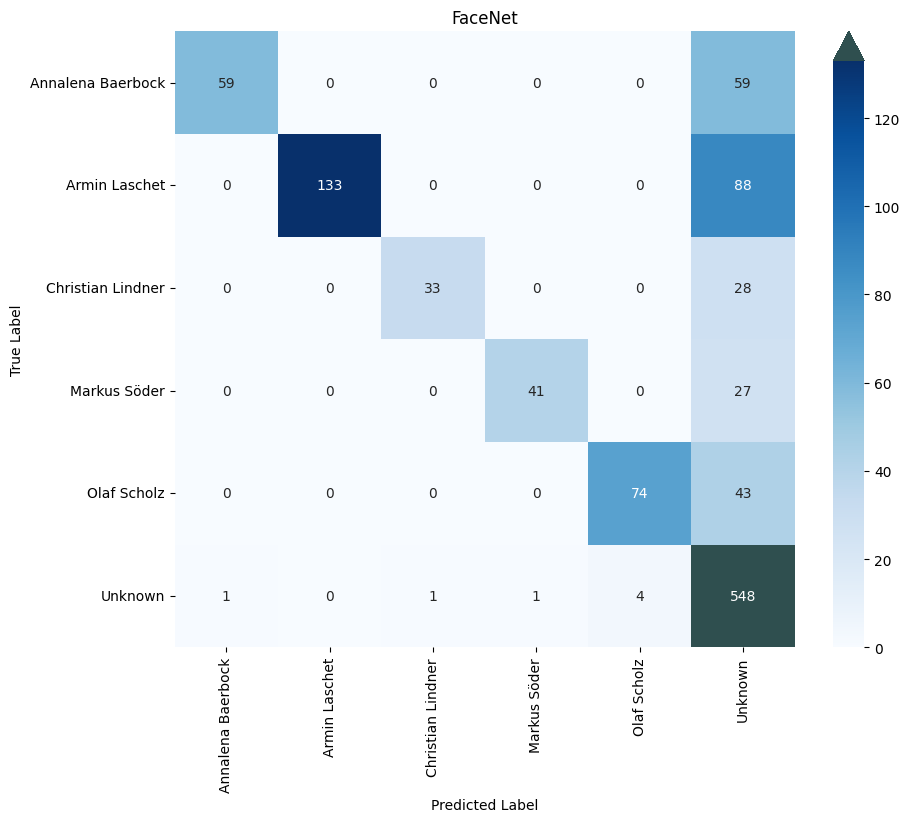

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Assuming 'df' is your DataFrame
labels = ['Annalena Baerbock', 'Armin Laschet',
          'Christian Lindner', 'Markus Söder', 'Olaf Scholz',  'Unknown']

# Generate the confusion matrix
cm = confusion_matrix(df['Candidate'], df['Candidate FaceNet'], labels=labels)

# Find the maximum value in the confusion matrix
max_value = 133

# Create a custom colormap
custom_cmap = sns.color_palette("Blues", as_cmap=True)
custom_cmap.set_over('darkslategray')  # Set the color for values above the maximum to red

# Plotting the confusion matrix with the custom colormap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, xticklabels=labels, yticklabels=labels, vmax=max_value, cbar_kws={'extend': 'max'})
plt.title('FaceNet')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


**Interrater Agreement**

In [ ]:
import krippendorff
import pandas as pd

def convert_to_reliability_data(matrix):
    transposed_matrix = matrix.T
    reliability_data = []
    for _, ratings in transposed_matrix.iterrows():
        reliability_data.append(ratings.tolist())
    return reliability_data

test_data = df[['11926', "11478", "11766", "9368", "11835", "9754", "11909", "11802", 'Candidate FaceNet']]
reliability_data = convert_to_reliability_data(test_data)   # contingency_matrix)

# Calculating Krippendorff's Alpha treating "Unsure" as a distinct category
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print("Krippendorff's Alpha:", alpha)

Krippendorff's Alpha: 0.6152751410670678


In [ ]:
#@title Qualitative Inspection
#@markdown Run this cell to generate a table comparing the Human and Model classifications.
images_per_label = 9  # @param {type: "slider", min: 1, max: 200}
credentials_file = "# REMOVED: GCP service account key not needed for local execution" # @param {type: "string"}

import json
from google.cloud import storage
from google.oauth2 import service_account
from datetime import timedelta, datetime
import pandas as pd
from IPython.display import display, HTML

# Group the DataFrame by 'Majority Decision'
filtered = df[df['Candidate'] != df['Candidate FaceNet']].copy()

# Load the credentials from the JSON file
with open(credentials_file, 'r') as f:
    credentials_info = json.load(f)

# Create credentials object from the service account information
credentials = service_account.Credentials.from_service_account_info(credentials_info)

# Create a storage client object using the credentials
storage_client = storage.Client(credentials=credentials)

# Set the expiration time to 7 days from now
expiration_time = timedelta(days=7)

# Iterate through the rows in the DataFrame and sign the URLs
for index, row in filtered.iterrows():
    # Split the gcloud URL to get bucket name and blob name
    bucket_name = "ig-politik-stories"
    blob_name = row['filename']

    # Get the bucket and blob objects
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(blob_name)

    # Generate the signed URL, passing the expiration time
    url = blob.generate_signed_url(expiration=datetime.utcnow() + expiration_time)
    filtered.loc[index, 'gcloud'] = url

grouped = filtered.groupby('Candidate')

# HTML template with Bootstrap
html_template = '''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/css/bootstrap.min.css" rel="stylesheet">
    <title>Grouped Images</title>
</head>
<body>
    <div class="container">
        {content}
    </div>
    <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/js/bootstrap.bundle.min.js"></script>
</body>
</html>
'''

# Generating the content for each group
content = ''
for decision, group in grouped:
    if images_per_label >= len(group):
      sample_size = len(group)
    else:
      sample_size = images_per_label

    sample = group.sample(sample_size)
    content += f'<h2>{decision}</h2>'
    content += '<div class="row">'
    for _, row in sample.iterrows():
        content += f'''
        <div class="col-md-4">
            <div class="card mb-4 shadow-sm">
                <img src="{row['gcloud']}" class="card-img-top" alt="{row['filename']}">
                <div class="card-body">
                    <p class="card-text">{row['filename']}</p>
                    <p class="card-text">FaceNet: {row['Candidate FaceNet']}</p>
                    <p class="card-text">Humans: {row['Candidate']}</p>
                </div>
            </div>
        </div>
        '''
    content += '</div>'

# Combine the content with the HTML template
html_output = html_template.format(content=content)

# Write the HTML to a file
with open('grouped_images_facenet.html', 'w') as file:
    file.write(html_output)

print("HTML file 'grouped_images_facenet.html' has been created.")

# Function to display the HTML in Colab
def display_html(file_path):
    with open(file_path, 'r') as file:
        html_content = file.read()
    display(HTML(html_content))

# Display the HTML file in the notebook
display_html('grouped_images_facenet.html')

## Evaluation GPT-4o

In [ ]:
gpt_df = pd.read_csv('data/2024-07-03-Faces-in-Stories-GPT.csv')

In [ ]:
gpt_df['GPT'] = gpt_df['GPT'].apply(lambda x: x.replace("['", ""))
gpt_df['GPT'] = gpt_df['GPT'].apply(lambda x: x.replace("']", ""))

In [ ]:
gpt_df['GPT'] = gpt_df['GPT'].apply(lambda x: False if x == "Unsure" or x == "False" else True)

In [ ]:
gpt_df

,filename,Ground Truth,Model,account_name,match_score,GPT,GPT Comment
0,abaerbock_13-09-2021_00:00_image0.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.412258,True,The image includes the name Annalena Baerbock ...
1,abaerbock_13-09-2021_00:00_image1.jpeg,"Unknown, Annalena Baerbock","Unknown, Annalena Baerbock",abaerbock,0.804533,True,NaN
2,abaerbock_13-09-2021_00:00_image2.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.629884,True,The image shows a person who appears to be Ann...
3,abaerbock_13-09-2021_00:00_image3.jpeg,Annalena Baerbock,Annalena Baerbock,abaerbock,0.570678,True,The image shows a person who appears to be Ann...
4,abaerbock_13-09-2021_00:00_image4.jpeg,Annalena Baerbock,Unknown,abaerbock,NaN,True,NaN
...,...,...,...,...,...,...,...
1166,spdde_26-09-2021_00:00_video4.jpeg,"Olaf Scholz, Unknown",Unknown,spdde,NaN,True,The image includes a poster with the SPD front...
1167,spdde_26-09-2021_00:00_video5.jpeg,Unknown,"Olaf Scholz, Unknown",spdde,0.889252,False,The image does not appear to picture Olaf Scho...
1168,spdde_26-09-2021_00:00_video6.jpeg,Unknown,Unknown,spdde,NaN,False,"The image does not clearly show Olaf Scholz, t..."
1169,spdde_26-09-2021_00:00_video7.jpeg,Unknown,Unknown,spdde,NaN,False,"The image does not picture Olaf Scholz, the fr..."


In [ ]:
def extract_candidate_gpt(row):
  if row['GPT'] == True:
    return accounts_dict[row['account_name']][0]
  else:
    return "Unknown"

gpt_df['Candidate GPT'] = gpt_df.apply(extract_candidate_gpt, axis=1)

In [ ]:
df = pd.merge(df, gpt_df[['filename', 'Candidate GPT']], on='filename', how='left')

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(df['Candidate'], df['Candidate GPT']))

                   precision    recall  f1-score   support

Annalena Baerbock       0.91      0.90      0.91       118
    Armin Laschet       0.84      0.93      0.88       221
Christian Lindner       0.88      0.92      0.90        61
     Markus Söder       0.89      0.87      0.88        68
      Olaf Scholz       0.85      0.90      0.88       117
          Unknown       0.90      0.85      0.88       555

         accuracy                           0.88      1140
        macro avg       0.88      0.89      0.89      1140
     weighted avg       0.88      0.88      0.88      1140



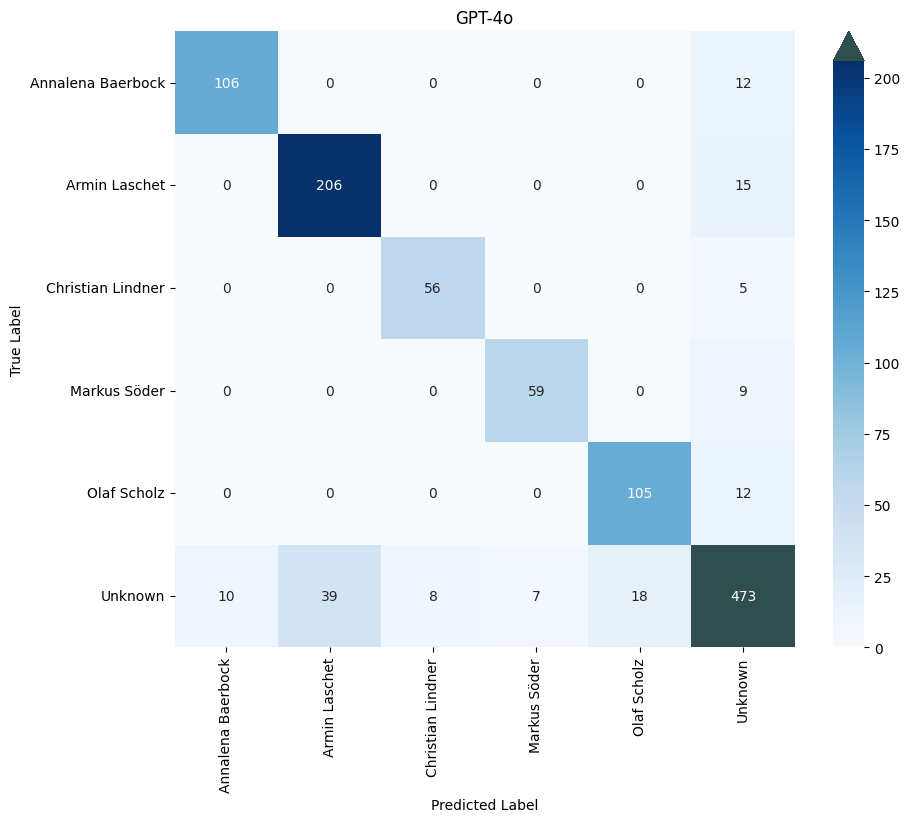

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Assuming 'df' is your DataFrame
labels = ['Annalena Baerbock', 'Armin Laschet',
          'Christian Lindner', 'Markus Söder', 'Olaf Scholz',  'Unknown']

# Generate the confusion matrix
cm = confusion_matrix(df['Candidate'], df['Candidate GPT'], labels=labels)

# Find the maximum value in the confusion matrix
max_value = 206

# Create a custom colormap
custom_cmap = sns.color_palette("Blues", as_cmap=True)
custom_cmap.set_over('darkslategray')  # Set the color for values above the maximum to red

# Plotting the confusion matrix with the custom colormap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, xticklabels=labels, yticklabels=labels, vmax=max_value, cbar_kws={'extend': 'max'})
plt.title('GPT-4o')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
import krippendorff
import pandas as pd

def convert_to_reliability_data(matrix):
    transposed_matrix = matrix.T
    reliability_data = []
    for _, ratings in transposed_matrix.iterrows():
        reliability_data.append(ratings.tolist())
    return reliability_data

test_data = df[['11926', "11478", "11766", "9368", "11835", "9754", "11909", "11802", 'Candidate GPT']]
reliability_data = convert_to_reliability_data(test_data)   # contingency_matrix)

# Calculating Krippendorff's Alpha treating "Unsure" as a distinct category
alpha = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print("Krippendorff's Alpha:", alpha)

Krippendorff's Alpha: 0.8548345341003087


In [ ]:
#@title Qualitative Inspection
#@markdown Run this cell to generate a table comparing the Human and Model classifications.
images_per_label = 9  # @param {type: "slider", min: 1, max: 200}
credentials_file = "# REMOVED: GCP service account key not needed for local execution" # @param {type: "string"}


import json
from google.cloud import storage
from google.oauth2 import service_account
from datetime import timedelta, datetime
import pandas as pd
from IPython.display import display, HTML

# Group the DataFrame by 'Majority Decision'
filtered = df[df['Candidate'] != df['Candidate GPT']].copy()

# Load the credentials from the JSON file
with open(credentials_file, 'r') as f:
    credentials_info = json.load(f)

# Create credentials object from the service account information
credentials = service_account.Credentials.from_service_account_info(credentials_info)

# Create a storage client object using the credentials
storage_client = storage.Client(credentials=credentials)

# Set the expiration time to 7 days from now
expiration_time = timedelta(days=7)

# Iterate through the rows in the DataFrame and sign the URLs
for index, row in filtered.iterrows():
    # Split the gcloud URL to get bucket name and blob name
    bucket_name = "ig-politik-stories"
    blob_name = row['filename']

    # Get the bucket and blob objects
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(blob_name)

    # Generate the signed URL, passing the expiration time
    url = blob.generate_signed_url(expiration=datetime.utcnow() + expiration_time)
    filtered.loc[index, 'gcloud'] = url

grouped = filtered.groupby('Candidate')

# HTML template with Bootstrap
html_template = '''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/css/bootstrap.min.css" rel="stylesheet">
    <title>Grouped Images</title>
</head>
<body>
    <div class="container">
        {content}
    </div>
    <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/js/bootstrap.bundle.min.js"></script>
</body>
</html>
'''

# Generating the content for each group
content = ''
for decision, group in grouped:

    if images_per_label >= len(group):
      sample_size = len(group)
    else:
      sample_size = images_per_label

    sample = group.sample(sample_size)
    content += f'<h2>{decision}</h2>'
    content += '<div class="row">'
    for _, row in sample.iterrows():
        content += f'''
        <div class="col-md-4">
            <div class="card mb-4 shadow-sm">
                <img src="{row['gcloud']}" class="card-img-top" alt="{row['filename']}">
                <div class="card-body">
                    <p class="card-text">{row['filename']}</p>
                    <p class="card-text">GPT-4o: {row['Candidate GPT']}</p>
                    <p class="card-text">Humans: {row['Candidate']}</p>
                </div>
            </div>
        </div>
        '''
    content += '</div>'

# Combine the content with the HTML template
html_output = html_template.format(content=content)

# Write the HTML to a file
with open('grouped_images_gpt.html', 'w') as file:
    file.write(html_output)

print("HTML file 'grouped_images_gpt.html' has been created.")

# Function to display the HTML in Colab
def display_html(file_path):
    with open(file_path, 'r') as file:
        html_content = file.read()
    display(HTML(html_content))

# Display the HTML file in the notebook
display_html('grouped_images_gpt.html')

## Let's take a look at the differences

In [ ]:
df[(df['Candidate GPT'] != df['Candidate FaceNet']) & (df['Candidate'] != "Unknown")][['filename', 'Candidate', 'Candidate FaceNet', 'Candidate GPT']]

In [ ]:
#@title Qualitative Inspection
#@markdown Run this cell to generate a table comparing the Human and Model classifications.
images_per_label = 200  # @param {type: "slider", min: 1, max: 200}
credentials_file = "# REMOVED: GCP service account key not needed for local execution" # @param {type: "string"}


import json
from google.cloud import storage
from google.oauth2 import service_account
from datetime import timedelta, datetime
import pandas as pd
from IPython.display import display, HTML

# Assuming df is your DataFrame, you need to have it loaded already.
# Group the DataFrame by 'Majority Decision'
filtered = df[(df['Candidate FaceNet'] == df['Candidate GPT']) & (df['Candidate FaceNet'] == "Unknown")].copy()


# Load the credentials from the JSON file
with open(credentials_file, 'r') as f:
    credentials_info = json.load(f)

# Create credentials object from the service account information
credentials = service_account.Credentials.from_service_account_info(credentials_info)

# Create a storage client object using the credentials
storage_client = storage.Client(credentials=credentials)

# Set the expiration time to 7 days from now
expiration_time = timedelta(days=7)

# Iterate through the rows in the DataFrame and sign the URLs
for index, row in filtered.iterrows():
    # Split the gcloud URL to get bucket name and blob name
    bucket_name = "ig-politik-stories"
    blob_name = row['filename']

    # Get the bucket and blob objects
    bucket = storage_client.bucket(bucket_name)
    blob = bucket.blob(blob_name)

    # Generate the signed URL, passing the expiration time
    url = blob.generate_signed_url(expiration=datetime.utcnow() + expiration_time)
    filtered.loc[index, 'gcloud'] = url

grouped = filtered.groupby('Candidate')

# HTML template with Bootstrap
html_template = '''
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1, shrink-to-fit=no">
    <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/css/bootstrap.min.css" rel="stylesheet">
    <style>
        @media print {{
            .page-break {{ page-break-before: always; }}
        }}
        .card img {{
            object-fit: cover;
        }}
    </style>
    <title>Grouped Images</title>
</head>
<body>
    <div class="container">
        <h1>Qualitative Inspection</h1>
        {content}
    </div>
    <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/js/bootstrap.bundle.min.js"></script>
</body>
</html>
'''

# Generating the content for each group
content = ''
card_count = 0
for decision, group in grouped:
    if images_per_label >= len(group):
        sample_size = len(group)
    else:
        sample_size = images_per_label

    sample = group.sample(sample_size)
    content += f'<h2>{decision}</h2>'
    content += '<div class="row">'
    for _, row in sample.iterrows():
        content += f'''
        <div class="col-md-4">
            <div class="card mb-4 shadow-sm">
                <img src="{row['gcloud']}" class="card-img-top" alt="{row['filename']}">
                <div class="card-body">
                    <p class="card-text">{row['filename']}</p>
                    <p class="card-text">GPT-4o: {row['Candidate GPT']}</p>
                    <p class="card-text">FaceNet: {row['Candidate FaceNet']}</p>
                </div>
            </div>
        </div>
        '''
        card_count += 1
        if card_count % 6 == 0:
            content += '</div><div class="page-break"></div><div class="row">'
    content += '</div>'

# Combine the content with the HTML template
html_output = html_template.format(content=content)

# Write the HTML to a file
with open('grouped_images_gpt.html', 'w') as file:
    file.write(html_output)

print("HTML file 'grouped_images_facenet.html' has been created.")

# Function to display the HTML in Colab
def display_html(file_path):
    with open(file_path, 'r') as file:
        html_content = file.read()
    display(HTML(html_content))

# Display the HTML file in the notebook
display_html('grouped_images_gpt.html')

What if we used both models combined?

In [ ]:
# Create the new column based on the conditions
df['Final Candidate'] = df.apply(
    lambda row: row['Candidate GPT'] if row['Candidate GPT'] != 'Unknown' else row['Candidate FaceNet'] if row['Candidate FaceNet'] != 'Unknown' else 'Unknown',
    axis=1
)

In [ ]:
df.head()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(df['Candidate'], df['Final Candidate']))

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Assuming 'df' is your DataFrame
labels = ['Annalena Baerbock', 'Armin Laschet',
          'Christian Lindner', 'Markus Söder', 'Olaf Scholz',  'Unknown']

# Generate the confusion matrix
cm = confusion_matrix(df['Candidate'], df['Final Candidate'], labels=labels)

# Find the maximum value in the confusion matrix
max_value = 206

# Create a custom colormap
custom_cmap = sns.color_palette("Blues", as_cmap=True)
custom_cmap.set_over('darkslategray')  # Set the color for values above the maximum to red

# Plotting the confusion matrix with the custom colormap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap=custom_cmap, xticklabels=labels, yticklabels=labels, vmax=max_value, cbar_kws={'extend': 'max'})
plt.title('GPT-4o')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
